## Laboratorio 8
### SVM

In [1]:
# Instalar librerias 
import importlib, subprocess, sys

# Asegurar librerías necesarias
required = {"pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn", "pyreadr": "pyreadr", "matplotlib":"matplotlib", "seaborn":"seaborn", "statsmodels":"statsmodels"}
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


1. Use los mismos conjuntos de entrenamiento y prueba de las hojas de trabajo pasadas para
probar el algoritmo.
2. Explore los datos y explique las transformaciones que debe hacerle para generar un modelo
de máquinas vectoriales de soporte.
3. Use como variable respuesta la variable categórica que especifica si la casa es barata, media o cara

In [2]:
# ACTIVIDAD 1, 2 Y 3: Preparación de datos, variable respuesta y transformaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("--- Cargando y limpiando datos ---")
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_model = df.loc[df['price'].notna() & (df['price'] > 0)].copy()

# ACTIVIDAD 3: Variable respuesta categórica (Barata, Media, Cara)
p33, p66 = df_model['price'].quantile([0.33, 0.66]).values
def definir_segmento(precio):
    if precio <= p33: return 'Económica'
    elif precio <= p66: return 'Intermedia'
    else: return 'Cara'
df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)
y = df_model['categoria_precio']

# Preparación de predictores
features_clas = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
X = df_model[features_clas].copy()

if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X = pd.concat([X, room_type_dummies], axis=1)
X = X.fillna(X.median(numeric_only=True))

# ACTIVIDAD 1: Mismos conjuntos de entrenamiento y prueba (semilla 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ACTIVIDAD 2: Transformaciones (Escalado StandardScaler vital para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Muestra para tuneo rápido (evitar horas de procesamiento)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_scaled, y_train, train_size=8000, stratify=y_train, random_state=42)

print(f"Datos listos. Dimensiones Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

# Inicializamos diccionarios para guardar resultados de las siguientes celdas
modelos_finales = {}
tiempos_procesamiento = {}

--- Cargando y limpiando datos ---
Datos listos. Dimensiones Train: (60996, 9) | Test: (15250, 9)


4. Genere varios (más de 2) modelos de SVM con diferentes kernels y distintos valores en los parámetros c, gamma (circular) y d (en caso de que utilice el polinomial). Puede tunear el modelo de forma automática siempre que explique los resultados.

In [3]:
# ACTIVIDAD 4: Generación de Modelos - SVM KERNEL LINEAL
print("1. Entrenando y tuneando SVM Kernel Lineal...")
inicio_lin = time.time()

# Usamos LinearSVC por eficiencia computacional en kernel lineal
grid_lin = GridSearchCV(LinearSVC(random_state=42, max_iter=2000, dual=False), 
                        {'C': [0.01, 0.1, 1, 10]}, cv=3, n_jobs=-1)
grid_lin.fit(X_train_scaled, y_train) 

modelos_finales['Lineal'] = grid_lin.best_estimator_
tiempos_procesamiento['Lineal'] = time.time() - inicio_lin

print(f"Mejores hiperparámetros (Lineal): {grid_lin.best_params_}")
print(f"Tiempo de procesamiento: {tiempos_procesamiento['Lineal']:.2f} segundos")

1. Entrenando y tuneando SVM Kernel Lineal...
Mejores hiperparámetros (Lineal): {'C': 1}
Tiempo de procesamiento: 3.39 segundos


In [4]:
# ACTIVIDAD 4: Generación de Modelos - SVM KERNEL RADIAL (RBF)
print("2. Entrenando y tuneando SVM Kernel Radial (RBF)...")
inicio_rbf = time.time()

# Tuneo usando la muestra reducida para viabilidad de tiempo
grid_rbf = GridSearchCV(SVC(kernel='rbf', random_state=42), 
                        {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1]}, cv=3, n_jobs=-1)
grid_rbf.fit(X_train_sub, y_train_sub) 

# Entrenamiento final con los mejores parámetros sobre todo el dataset
svm_rbf = SVC(**grid_rbf.best_params_, kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train) 

modelos_finales['Radial'] = svm_rbf
tiempos_procesamiento['Radial'] = time.time() - inicio_rbf

print(f"Mejores hiperparámetros (Radial): {grid_rbf.best_params_}")
print(f"Tiempo de procesamiento: {tiempos_procesamiento['Radial']:.2f} segundos")

2. Entrenando y tuneando SVM Kernel Radial (RBF)...
Mejores hiperparámetros (Radial): {'C': 0.1, 'gamma': 0.1}
Tiempo de procesamiento: 78.67 segundos


In [7]:
# ACTIVIDAD 4: Generación de Modelos - SVM KERNEL POLINOMIAL
print("3. Entrenando y tuneando SVM Kernel Polinomial...")
inicio_poly = time.time()

grid_poly = GridSearchCV(SVC(kernel='poly', random_state=42, max_iter=200000, tol=1e-2), 
                         {'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale', 0.1], 'coef0': [0.0, 1.0]}, cv=3, n_jobs=-1)
grid_poly.fit(X_train_sub, y_train_sub) 

svm_poly = SVC(**grid_poly.best_params_, kernel='poly', random_state=42, max_iter=200000, tol=1e-2)
svm_poly.fit(X_train_sub, y_train_sub)

modelos_finales['Polinomial'] = svm_poly
tiempos_procesamiento['Polinomial'] = time.time() - inicio_poly

print(f"Mejores hiperparámetros (Polinomial): {grid_poly.best_params_}")
print(f"Tiempo de procesamiento: {tiempos_procesamiento['Polinomial']:.2f} segundos")

3. Entrenando y tuneando SVM Kernel Polinomial...
Mejores hiperparámetros (Polinomial): {'C': 1, 'coef0': 1.0, 'degree': 2, 'gamma': 'scale'}
Tiempo de procesamiento: 7.48 segundos


5. Use los modelos para predecir el valor de la variable respuesta
6. Haga las matrices de confusión respectivas.


--- REPORTE CLASIFICACIÓN: SVM LINEAL ---
              precision    recall  f1-score   support

        Cara       0.62      0.74      0.67      5141
   Económica       0.61      0.66      0.64      4983
  Intermedia       0.48      0.35      0.40      5126

    accuracy                           0.58     15250
   macro avg       0.57      0.58      0.57     15250
weighted avg       0.57      0.58      0.57     15250


--- REPORTE CLASIFICACIÓN: SVM RADIAL ---
              precision    recall  f1-score   support

        Cara       0.64      0.73      0.68      5141
   Económica       0.65      0.63      0.64      4983
  Intermedia       0.48      0.43      0.45      5126

    accuracy                           0.59     15250
   macro avg       0.59      0.59      0.59     15250
weighted avg       0.59      0.59      0.59     15250


--- REPORTE CLASIFICACIÓN: SVM POLINOMIAL ---
              precision    recall  f1-score   support

        Cara       0.63      0.74      0.68      5

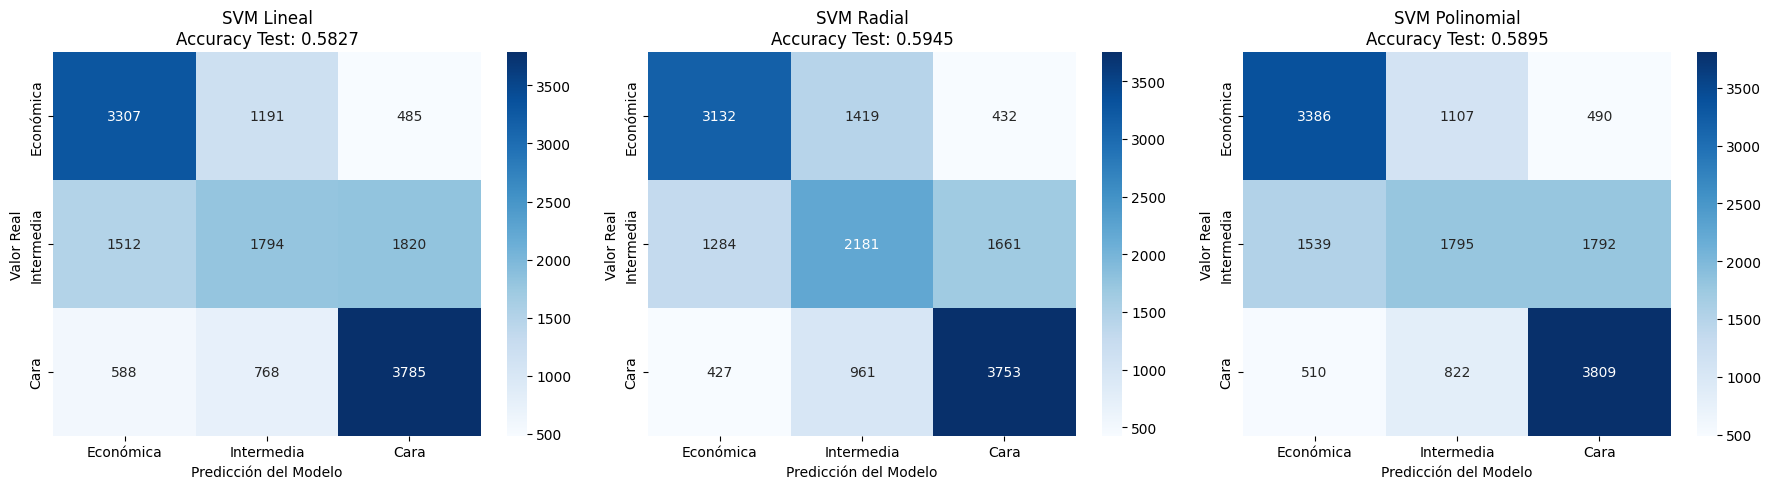

In [8]:
# ACTIVIDADES 5 Y 6: Predicciones y Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_orden = ['Económica', 'Intermedia', 'Cara']
resultados_train_test = []

for i, (nombre, modelo) in enumerate(modelos_finales.items()):
    # ACTIVIDAD 5: Predecir el valor de la variable respuesta
    y_pred_train = modelo.predict(X_train_scaled)
    y_pred_test = modelo.predict(X_test_scaled)
    
    # Guardamos métricas para la Actividad 7
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    resultados_train_test.append({
        'Modelo': nombre,
        'Acc Train': acc_train,
        'Acc Test': acc_test,
        'Diferencia': acc_train - acc_test
    })
    
    print(f"\n--- REPORTE CLASIFICACIÓN: SVM {nombre.upper()} ---")
    print(classification_report(y_test, y_pred_test))
    
    # ACTIVIDAD 6: Matrices de Confusión
    cm = confusion_matrix(y_test, y_pred_test, labels=labels_orden)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels_orden, yticklabels=labels_orden, ax=axes[i])
    axes[i].set_title(f'SVM {nombre}\nAccuracy Test: {acc_test:.4f}')
    axes[i].set_ylabel('Valor Real')
    axes[i].set_xlabel('Predicción del Modelo')

plt.tight_layout()
plt.show()

7. Analice si los modelos están sobre ajustados o desajustados. ¿Qué puede hacer para
manejar el sobreajuste o desajuste?

In [9]:
# ACTIVIDAD 7: Análisis de Sobreajuste o Desajuste
df_sobreajuste = pd.DataFrame(resultados_train_test)

print("=== TABLA DE ANÁLISIS DE AJUSTE (TRAIN VS TEST) ===")
print(df_sobreajuste.to_string(index=False))
print("\nNota para análisis:")
print("- Si el 'Acc Train' es mucho mayor que 'Acc Test' (> 0.05 de diferencia), hay SOBREAJUSTE (Memorización).")
print("- Si ambas métricas son bajas (< 0.50), hay DESAJUSTE (El modelo no aprende los patrones).")
print("- Si la diferencia es muy pequeña y el accuracy es aceptable, el modelo generaliza bien.")

=== TABLA DE ANÁLISIS DE AJUSTE (TRAIN VS TEST) ===
    Modelo  Acc Train  Acc Test  Diferencia
    Lineal   0.580874  0.582689   -0.001814
    Radial   0.593531  0.594492   -0.000961
Polinomial   0.590662  0.589508    0.001153

Nota para análisis:
- Si el 'Acc Train' es mucho mayor que 'Acc Test' (> 0.05 de diferencia), hay SOBREAJUSTE (Memorización).
- Si ambas métricas son bajas (< 0.50), hay DESAJUSTE (El modelo no aprende los patrones).
- Si la diferencia es muy pequeña y el accuracy es aceptable, el modelo generaliza bien.
